In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from transformers import AutoTokenizer, AutoModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, cohen_kappa_score
from scipy.stats import pearsonr

from tqdm import tqdm

In [15]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 16
EPOCHS = 10
PATIENCE = 3
LEARNING_RATE = 1e-5
MAX_LENGTH = 384
RANDOM_SEED = 42
WARMUP_RATIO = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Device:", DEVICE)

Device: cuda


In [16]:
df = pd.read_csv(
    "task1_cleaned_final.csv",
    engine="python",
    on_bad_lines="skip"
)
df

criteria_cols = [
    "Task_Achievement",
    "Coherence_Cohesion",
    "Lexical_Resource",
    "Range_Accuracy"
]

features = [
    "word_count",
    "unique_words",
    "ttr",
    "avg_word_len",
    "sentence_count",
    "avg_sentence_len",
    "sentence_len_var",
    "long_word_ratio",
    "short_word_ratio",
    "punct_density",
]

df = df.dropna(subset=criteria_cols + ["Essay"]).reset_index(drop=True)

print("Total essays:", len(df))

Total essays: 8327


In [17]:
df[criteria_cols] = df[criteria_cols] / 9.0

criteria = torch.tensor(df[criteria_cols].values, dtype=torch.float32)


criteria

tensor([[0.6667, 0.5556, 0.5556, 0.5000],
        [0.8333, 0.7778, 0.7778, 0.7778],
        [0.7222, 0.6111, 0.6111, 0.5000],
        ...,
        [1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]])

In [18]:
idx = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.3,
    random_state=RANDOM_SEED,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=2/3,
    random_state=RANDOM_SEED
)

print(len(train_idx), len(val_idx), len(test_idx))

5828 833 1666


In [19]:
scaler = StandardScaler()
df[features] = df[features].astype(float)

df_features = df[features].copy()

df.loc[train_idx, features] = scaler.fit_transform(df.loc[train_idx, features])
df.loc[val_idx, features] = scaler.transform(df.loc[val_idx, features])
df.loc[test_idx, features] = scaler.transform(df.loc[test_idx, features])

In [20]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/mpnet-base")

encoded = tokenizer(
    df["Essay"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

input_ids = encoded["input_ids"]
attention_mask = encoded["attention_mask"]

feat_tensor = torch.tensor(df[features].values, dtype=torch.float32)

In [21]:
train_dataset = TensorDataset(
    input_ids[train_idx],
    attention_mask[train_idx],
    criteria[train_idx],
    feat_tensor[train_idx]
)

val_dataset = TensorDataset(
    input_ids[val_idx],
    attention_mask[val_idx],
    criteria[val_idx],
    feat_tensor[val_idx]
)

test_dataset = TensorDataset(
    input_ids[test_idx],
    attention_mask[test_idx],
    criteria[test_idx],
    feat_tensor[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [ ]:
class MPNetIELTS(nn.Module):

    def __init__(self):
        super().__init__()

        self.mpnet = AutoModel.from_pretrained("microsoft/mpnet-base")

        hidden_size = self.mpnet.config.hidden_size
        feature_dim = len(features)

        # FEATURE ATTENTION
        self.feature_attention = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.Tanh(),
            nn.Linear(feature_dim, feature_dim),
            nn.Softmax(dim=1)
        )

        # feature projection 
        self.feature_proj = nn.Linear(feature_dim, 64)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        self.criteria_head = nn.Linear(256, 4)

    def forward(self, ids, mask, feats):

        outputs = self.mpnet(ids, attention_mask=mask)

        last_hidden = outputs.last_hidden_state

        mask_expanded = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_hidden = torch.sum(last_hidden * mask_expanded, dim=1)
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)

        mean_pool = sum_hidden / sum_mask

        attn_weights = self.feature_attention(feats)
        feats_weighted = feats * attn_weights

        feats_proj = self.feature_proj(feats_weighted)

        # concat
        x = torch.cat([mean_pool, feats_proj], dim=1)

        x = self.fc(x)

        crit = torch.sigmoid(self.criteria_head(x)) * 0.95 + 0.025

        return crit

In [23]:
model = MPNetIELTS().to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

criterion = nn.MSELoss()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: microsoft/mpnet-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

In [25]:
best_val = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

logs = []

In [26]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()

    train_loss = 0

    for ids, mask, crit, feat_batch in tqdm(train_loader):

        ids = ids.to(DEVICE)
        mask = mask.to(DEVICE)
        crit = crit.to(DEVICE)
        feat_batch = feat_batch.to(DEVICE)
    
        feat_noise = feat_batch + torch.randn_like(feat_batch) * 0.01

        optimizer.zero_grad()

        crit_pred = model(ids, mask, feat_noise)

        loss = criterion(crit_pred, crit)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for ids, mask, crit, feat_batch in val_loader:

            ids = ids.to(DEVICE)
            mask = mask.to(DEVICE)
            crit = crit.to(DEVICE)
            feat_batch = feat_batch.to(DEVICE)

            crit_pred = model(ids, mask, feat_batch)

            loss = criterion(crit_pred, crit)

            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)

    print("Train Loss:", avg_train)
    print("Val Loss:", avg_val)

    logs.append({
        "epoch": epoch + 1,
        "train_loss": avg_train,
        "val_loss": avg_val
    })

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    if avg_val < best_val:
        best_val = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "mpnet_final.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break


Epoch 1/10


100%|██████████| 365/365 [00:37<00:00,  9.82it/s]


Train Loss: 0.06120467338557929
Val Loss: 0.03557641092547268

Epoch 2/10


100%|██████████| 365/365 [00:38<00:00,  9.59it/s]


Train Loss: 0.02602669956570823
Val Loss: 0.01267219319904469

Epoch 3/10


...

Train Loss: 0.006174069202875029
Val Loss: 0.011224179080564459

Epoch 8/10


100%|██████████| 365/365 [00:37<00:00,  9.64it/s]


Train Loss: 0.005854971410885249
Val Loss: 0.010009771819173728

Epoch 9/10


100%|██████████| 365/365 [00:37<00:00,  9.77it/s]


Train Loss: 0.005552214197176573
Val Loss: 0.009771095878743339
Early stopping


In [27]:
log_df = pd.DataFrame(logs)

log_df.to_csv(
    "mpnet.csv",
    index=False
)

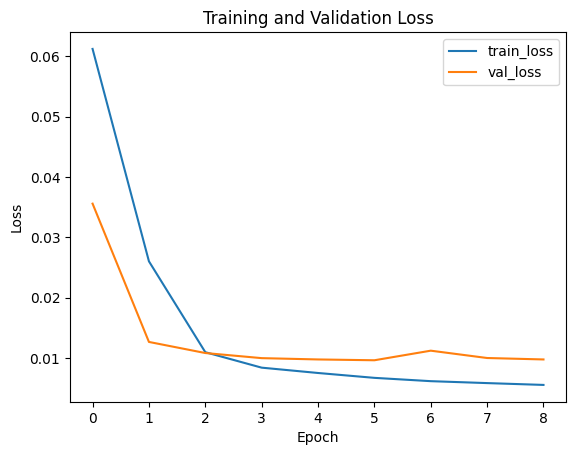

In [28]:
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [29]:
model.load_state_dict(torch.load("mpnet_final.pt", map_location=DEVICE))
model.eval()

MPNetIELTS(
  (mpnet): MPNetModel(
    (embeddings): MPNetEmbeddings(
      (word_embeddings): Embedding(30527, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): MPNetEncoder(
      (layer): ModuleList(
        (0-11): 12 x MPNetLayer(
          (attention): MPNetAttention(
            (attn): MPNetSelfAttention(
              (q): Linear(in_features=768, out_features=768, bias=True)
              (k): Linear(in_features=768, out_features=768, bias=True)
              (v): Linear(in_features=768, out_features=768, bias=True)
              (o): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
         

In [30]:
preds = []
trues = []

with torch.no_grad():

    for ids, mask, crit, feat_batch in test_loader:

        ids = ids.to(DEVICE)
        mask = mask.to(DEVICE)
        feat_batch = feat_batch.to(DEVICE)

        crit_pred = model(ids, mask, feat_batch)

        preds.append(crit_pred.cpu().numpy())
        trues.append(crit.cpu().numpy())

pred = np.concatenate(preds) * 9
true = np.concatenate(trues) * 9

pred_overall = pred.mean(axis=1)
true_overall = true.mean(axis=1)

In [31]:
mae = mean_absolute_error(true_overall, pred_overall)

rmse = np.sqrt(mean_squared_error(true_overall, pred_overall))

pearson = pearsonr(true_overall, pred_overall)[0]

rounded_preds = np.round(pred_overall * 2) / 2
within_half = np.mean(np.abs(rounded_preds - true_overall) <= 0.5)

true_band = np.round(true_overall * 2).astype(int)
pred_band = np.round(pred_overall * 2).astype(int)

qwk = cohen_kappa_score(true_band, pred_band, weights="quadratic")

print("\nTEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("Pearson:", pearson)
print("Within ±0.5:", within_half)
print("QWK:", qwk)


TEST RESULTS
MAE: 0.617351770401001
RMSE: 0.792285041898411
Pearson: 0.8760188
Within ±0.5: 0.5744297719087635
QWK: 0.8478195161364946


In [32]:
def ielts_round(score):
    integer = int(score)
    decimal = score - integer

    if decimal < 0.25:
        return integer
    elif decimal <= 0.5:
        return integer + 0.5
    elif decimal < 0.75:
        return integer + 0.5
    else:
        return integer + 1

In [33]:
import re
def predict_task1_score(essay):

    model.eval()

    text = essay.lower()

    tokens = re.findall(r'\b\w+\b', text)
    word_count = len(tokens)
    unique_words = len(set(tokens))
    ttr = unique_words / word_count if word_count > 0 else 0

    avg_word_len = np.mean([len(w) for w in tokens]) if word_count > 0 else 0

    sentences = re.split(r'[.!?]+', essay)
    sentences = [s for s in sentences if s.strip() != ""]

    sentence_count = len(sentences)

    avg_sentence_len = word_count / sentence_count if sentence_count > 0 else 0

    sentence_len_var = np.var([len(s.split()) for s in sentences]) if sentence_count > 0 else 0

    long_word_ratio = np.mean([len(w) > 6 for w in tokens]) if word_count > 0 else 0
    short_word_ratio = np.mean([len(w) <= 3 for w in tokens]) if word_count > 0 else 0

    punct_count = len(re.findall(r'[,.!?;:]', essay))
    punct_density = punct_count / word_count if word_count > 0 else 0

    feature_vector = [
        word_count,
        unique_words,
        ttr,
        avg_word_len,
        sentence_count,
        avg_sentence_len,
        sentence_len_var,
        long_word_ratio,
        short_word_ratio,
        punct_density
    ]

    # ===== SCALE FEATURE =====
    feature_vector = scaler.transform([feature_vector])

    feat_tensor = torch.tensor(feature_vector, dtype=torch.float32).to(DEVICE)

    # ===== TOKENIZER =====
    encoded = tokenizer(
        essay,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    ids = encoded["input_ids"].to(DEVICE)
    mask = encoded["attention_mask"].to(DEVICE)

    # ===== PREDICT =====
    with torch.no_grad():
        crit = model(ids, mask, feat_tensor)

    crit = crit.squeeze(0).cpu().numpy() * 9
    overall = np.mean(crit)

    return {
        "Task_Achievement": crit[0],
        "Coherence_Cohesion": crit[1],
        "Lexical_Resource": crit[2],
        "Range_Accuracy": crit[3],
        "Overall": ielts_round(overall)
    }

In [34]:
result_6 = predict_task1_score(
    essay="""The chart illustrates the proportion of income and expenditure at different ages in 2013.

Overall, it is clearly seen that there are significant changes. Citizens who under 25 years and older than 75 years are nearly had the same income and spending ratio. While people aged from 35 to 54 years had the highest income rates with plummeted expenditure.

To begin with, it is evident that individuals at 35 to 54 years who had the highest income rates of just under 80000$, spend approximately 60000$, saving the rest of their income. Additionally, younger and old age citizens have almost the same income and spending ratio of 30000$ and 33000$ respectively.

Furthermore, as explained in the chart, people between 25 to 34 years have a high income of just under 60000$, and expenditure nearly at 48000$. Also, the rate of income and spending recorded a decline from 55 to 74 years.
""")

for k, v in result_6.items():
    print(k, ":", v)

Task_Achievement : 6.2251787
Coherence_Cohesion : 5.260896
Lexical_Resource : 5.3419576
Range_Accuracy : 4.9520698
Overall : 5.5


/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [35]:
result_7 = predict_task1_score(
    essay="""This graph compares how much Americans spent to how much income they made in 2013, by age group.

Overall, the data illustrated an overall rise and fall in both income and spending between young, middle-aged, and older Americans. The highest salary and expenditure went to the adults whilst the youngsters provided the smallest number. Subsequently, the significant difference from the earning and consumption belonged to the middle-aged group.

Those under 25 and over 75 actually spent slightly more than they earned. In contrast, between the ages of 25 and 64, Americans earned 10,000 to 20,000 dollars more than they spent. This difference shrinks in the 65-74 age group, where spending was just a few thousand dollars less.

In terms of actual numbers, those under 25 or over 75 earned and spent around 30,000 and 35,000 dollars, respectively. 25-34 year-olds and 65-74 year-olds both earned in the 50,000s and spent in the 40,000s. In the middle, between ages 35 and 64, income was 70,000-80,000 dollars, and spending ranged from roughly 55 to 60 thousand.
 """)

for k, v in result_7.items():
    print(k, ":", v)

Task_Achievement : 7.377006
Coherence_Cohesion : 7.0227966
Lexical_Resource : 6.9434433
Range_Accuracy : 7.006012
Overall : 7


/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


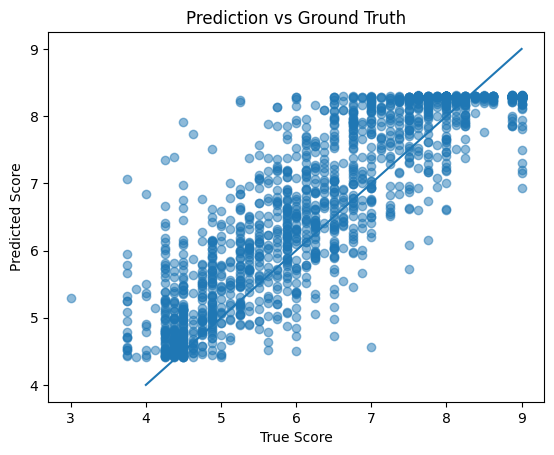

In [36]:
plt.scatter(true_overall, pred_overall, alpha=0.5)
plt.plot([4,9], [4,9])  

plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("Prediction vs Ground Truth")
plt.show()

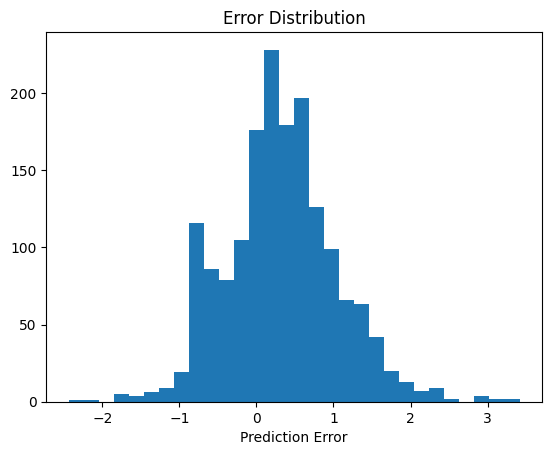

In [37]:
errors = pred_overall - true_overall

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.show()